# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
Business_Understanding = { "BackGround":(
                              " The dataset used in this practical application was collected from a Portugese bank."
                          ), 
                          "Data_Info":(
                              "It consists of 17 directed telephone marketing campains conducted between May 2008" 
                              "and November 2010."
                          ),
                          "Initial_Results":(
                              "Across thes campaigns, a total of 79354 contacts were made, with approximately only 8% "
                              "ending up with the subscription of offered long-term deposit product."
                          ),
                          "Initial_Feedback": (
                              "Even though its successful rate is notably higher than that of tranditional"
                              " mass campaigns, it remains relatively low. This highlights the need to "
                              "develop predictive model that can improve targeting efficiency and"
                              " reduce unnecssary contact effors."
                          )
                         }

for topic, description in Business_Understanding.items():
    print(f"•{description}\n")

• The dataset used in this practical application was collected from a Portugese bank.

•It consists of 17 directed telephone marketing campains conducted between May 2008and November 2010.

•Across thes campaigns, a total of 79354 contacts were made, with approximately only 8% ending up with the subscription of offered long-term deposit product.

•Even though its successful rate is notably higher than that of tranditional mass campaigns, it remains relatively low. This highlights the need to develop predictive model that can improve targeting efficiency and reduce unnecssary contact effors.



### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd
import numpy as np

In [3]:
campaign_Origional_DF = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
campaign_Origional_DF.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
campaign_Origional_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
campaign_Origional_DF.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [7]:
import matplotlib.pyplot as plt

def build_feature_table_figure(feature_groups, type_groups, description_groups):
    rows = []
    for group in feature_groups:
        for feature, dtype, desc in zip(
            feature_groups[group],
            type_groups[group],
            description_groups[group]
        ):
            rows.append([group, feature, dtype, desc])
    fig, ax = plt.subplots(figsize=(13, 12))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["Category", "Name", "Type", "Description and Values"],
        cellLoc="center",
        colLoc="center",
        colWidths=[0.28, 0.18, 0.14, 0.40],
        bbox=[0, 0, 1, 0.95]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1, 1.5)

    ncols = 4
    nrows = len(rows)
    for c in range(ncols):
        cell = table[(0, c)]
        cell.set_facecolor("white")
        cell.set_text_props(weight="bold", color="black", ha="center")
        cell.set_edgecolor("black")
        cell.set_linewidth(1.5)
    for r in range(1, nrows + 1):
        for c in range(ncols):
            cell = table[(r, c)]
            cell.set_edgecolor("black")
            cell.set_linewidth(1.0)
        table[(r, 0)].set_text_props(weight="bold")   
        table[(r, 1)].set_text_props(weight="bold")   
        table[(r, 2)].set_text_props(ha="center")     
        table[(r, 3)].set_text_props(ha="center")       
    plt.show()

In [8]:
feature_groups = {
    "Bank client data" : (campaign_Origional_DF.columns[0:7]),
    "Last contact infomration" : (campaign_Origional_DF.columns[7:11]),
    "Compaign history attributes" : (campaign_Origional_DF.columns[11:15]),
    "Social&Economic attributes" : (campaign_Origional_DF.columns[15:20])
}

type_groups = {
    "Bank client data" : ("Numeric","Categorical","Categorical","Categorical","Categorical","Categorical","Categorical"),
    "Last contact infomration" : ("Categorical","Categorical","Categorical","Numeric"),
    "Compaign history attributes" : ("Numeric","Numeric","Numeric","Categorical"),
    "Social&Economic attributes" : ("Numeric","Numeric","Numeric","Numeric","Numeric")
}

description_groups = {
    "Bank client data" : ("Age at the contact date","Type of job","Marital status","Degree Level","Has credit in default?","Has housing loan?","Has personal loan?"),
    "Last contact infomration" : ("Contact communication type","Last contact month of year","Last contact day of the week","Last contact duration,in seconds"),
    "Compaign history attributes" : ("Number of contacts performed","Number of days that passed","Number of contacts performed before compaign","Outcome of the previous marketing campaign"),
    "Social&Economic attributes" : ("Employment variation rate","Consumer price index","Consumer confidence index","Euribor 3 month rate","Number of employees")
}


•  The dataset contains 20 input variables consisting of both numerical and categorical data type. These varaibles can be grouped into four main categories:
     • Bank client data. 
     • Last contact infomration from the current campaign. 
     • Compain history attributes. 
     • Social and economic context attributes.

•  The output represents wether the client subscribed a term deposit.

•  The details of each input variable are listed in below table:


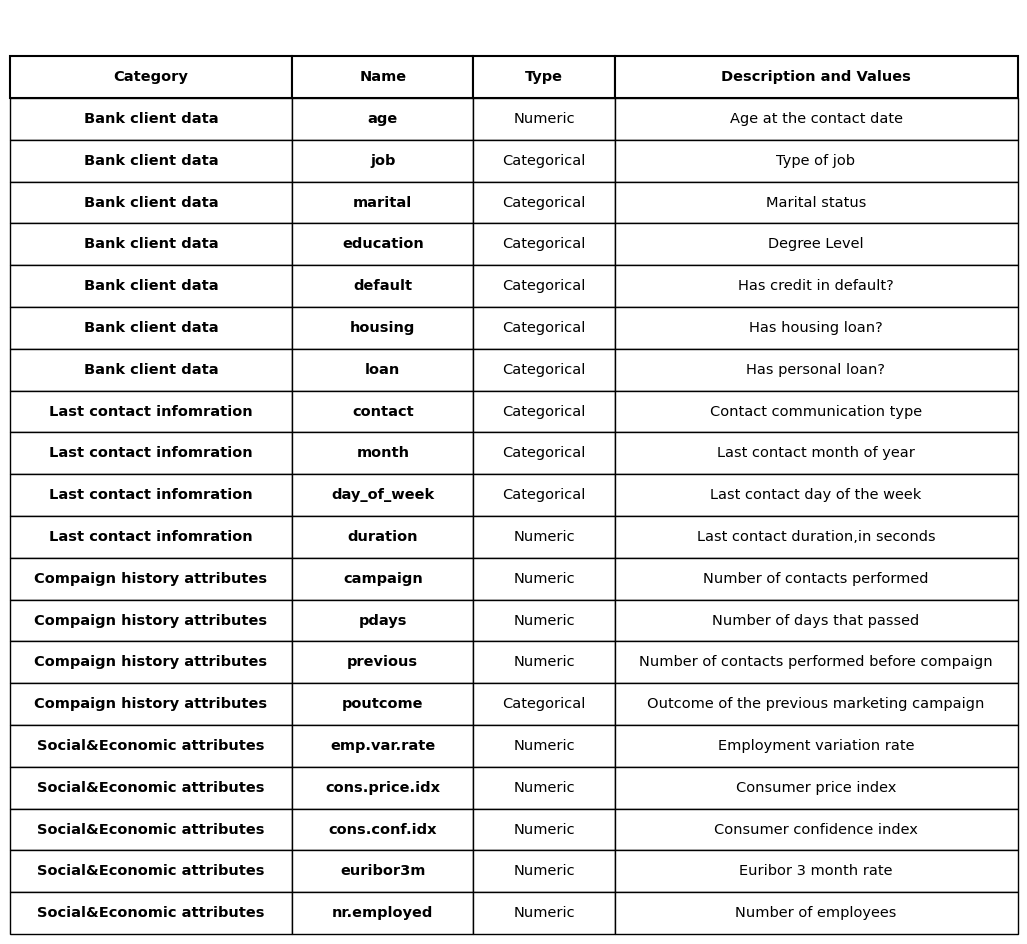

In [9]:
Understanding_the_Features = { "Input":(
                                  "  The dataset contains 20 input variables consisting of both numerical "
                                  "and categorical data type. These varaibles can be grouped into four main categories:\n"
                                  "     • Bank client data. \n"
                                  "     • Last contact infomration from the current campaign. \n"
                                  "     • Compain history attributes. \n"
                                  "     • Social and economic context attributes.\n"
                                        ),
                              "Output":(
                                  "  The output represents wether the client subscribed a term deposit.\n"
                                        ),
                              "Detail":(
                                  "  The details of each input variable are listed in below table:"
                                        )
                         }
for topic, description in Understanding_the_Features.items():
    print(f"•{description}")

build_feature_table_figure(feature_groups, type_groups, description_groups)

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [10]:
Understanding_the_Task = {
    "Business_Objectives" :(
        "  The objective of this taks is to improve the successful rate of direct marketing campaign by identifying clients "
        "who are more likely to subscribe to a term deposit. Given the avaliable input variables, inclduing bank client data, "
        "last contact information, compain history, and social & economic attributes, the goal is to "
        "reduce unnecessary contact attempts"
    ),
    "Model_to_compare":(
        "  The models to be compared inclde KNN, logistic regression, decision trees, and SVM."
    ),
    "Success_Certeria":(
        "  Model perforamnce will be evaluted using training time, train and test accuracy"
    )
}
for topic, description in Understanding_the_Task.items():
    print(f"•{description}\n")

•  The objective of this taks is to improve the successful rate of direct marketing campaign by identifying clients who are more likely to subscribe to a term deposit. Given the avaliable input variables, inclduing bank client data, last contact information, compain history, and social & economic attributes, the goal is to reduce unnecessary contact attempts

•  The models to be compared inclde KNN, logistic regression, decision trees, and SVM.

•  Model perforamnce will be evaluted using training time, train and test accuracy



### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [11]:
# Drop the coloumn of duration as requested. It is not usable for real prediction
campaign_No_Duration = campaign_Origional_DF.drop(columns=['duration'])
# Drop 999 pdays to a new numerical binary columns called fistTimeCall, since 999 is encoded with a catgorical meaning,
# which is different to other data in the pdays column
campaign_Column_Separation = campaign_No_Duration.copy()
campaign_Column_Separation['is_firstTime_Call'] = (campaign_Column_Separation['pdays'] == 999).astype(int)
campaign_Column_Separation['pdays'] = campaign_Column_Separation['pdays'].replace(999,0)
#Target Encoding
campaign_Target_Encoding = campaign_Column_Separation.copy()
campaign_Target_Encoding['y'] = campaign_Target_Encoding['y'].map({'yes':1,'no':0})
#Feature Separation
X = campaign_Target_Encoding.drop('y',axis=1)
Y = campaign_Target_Encoding['y']

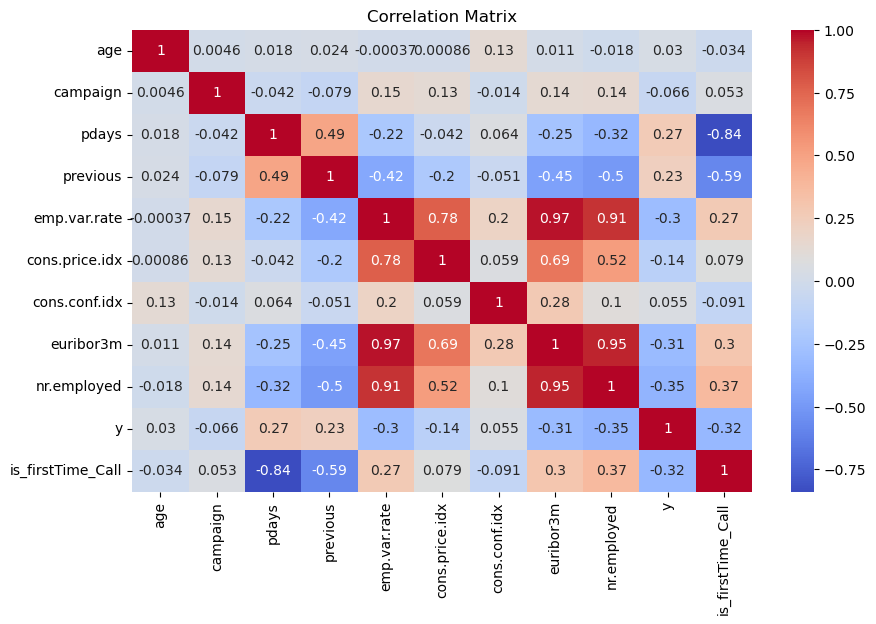

In [12]:
#Understand the correlation of each numerical category with the target column
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(campaign_Target_Encoding.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

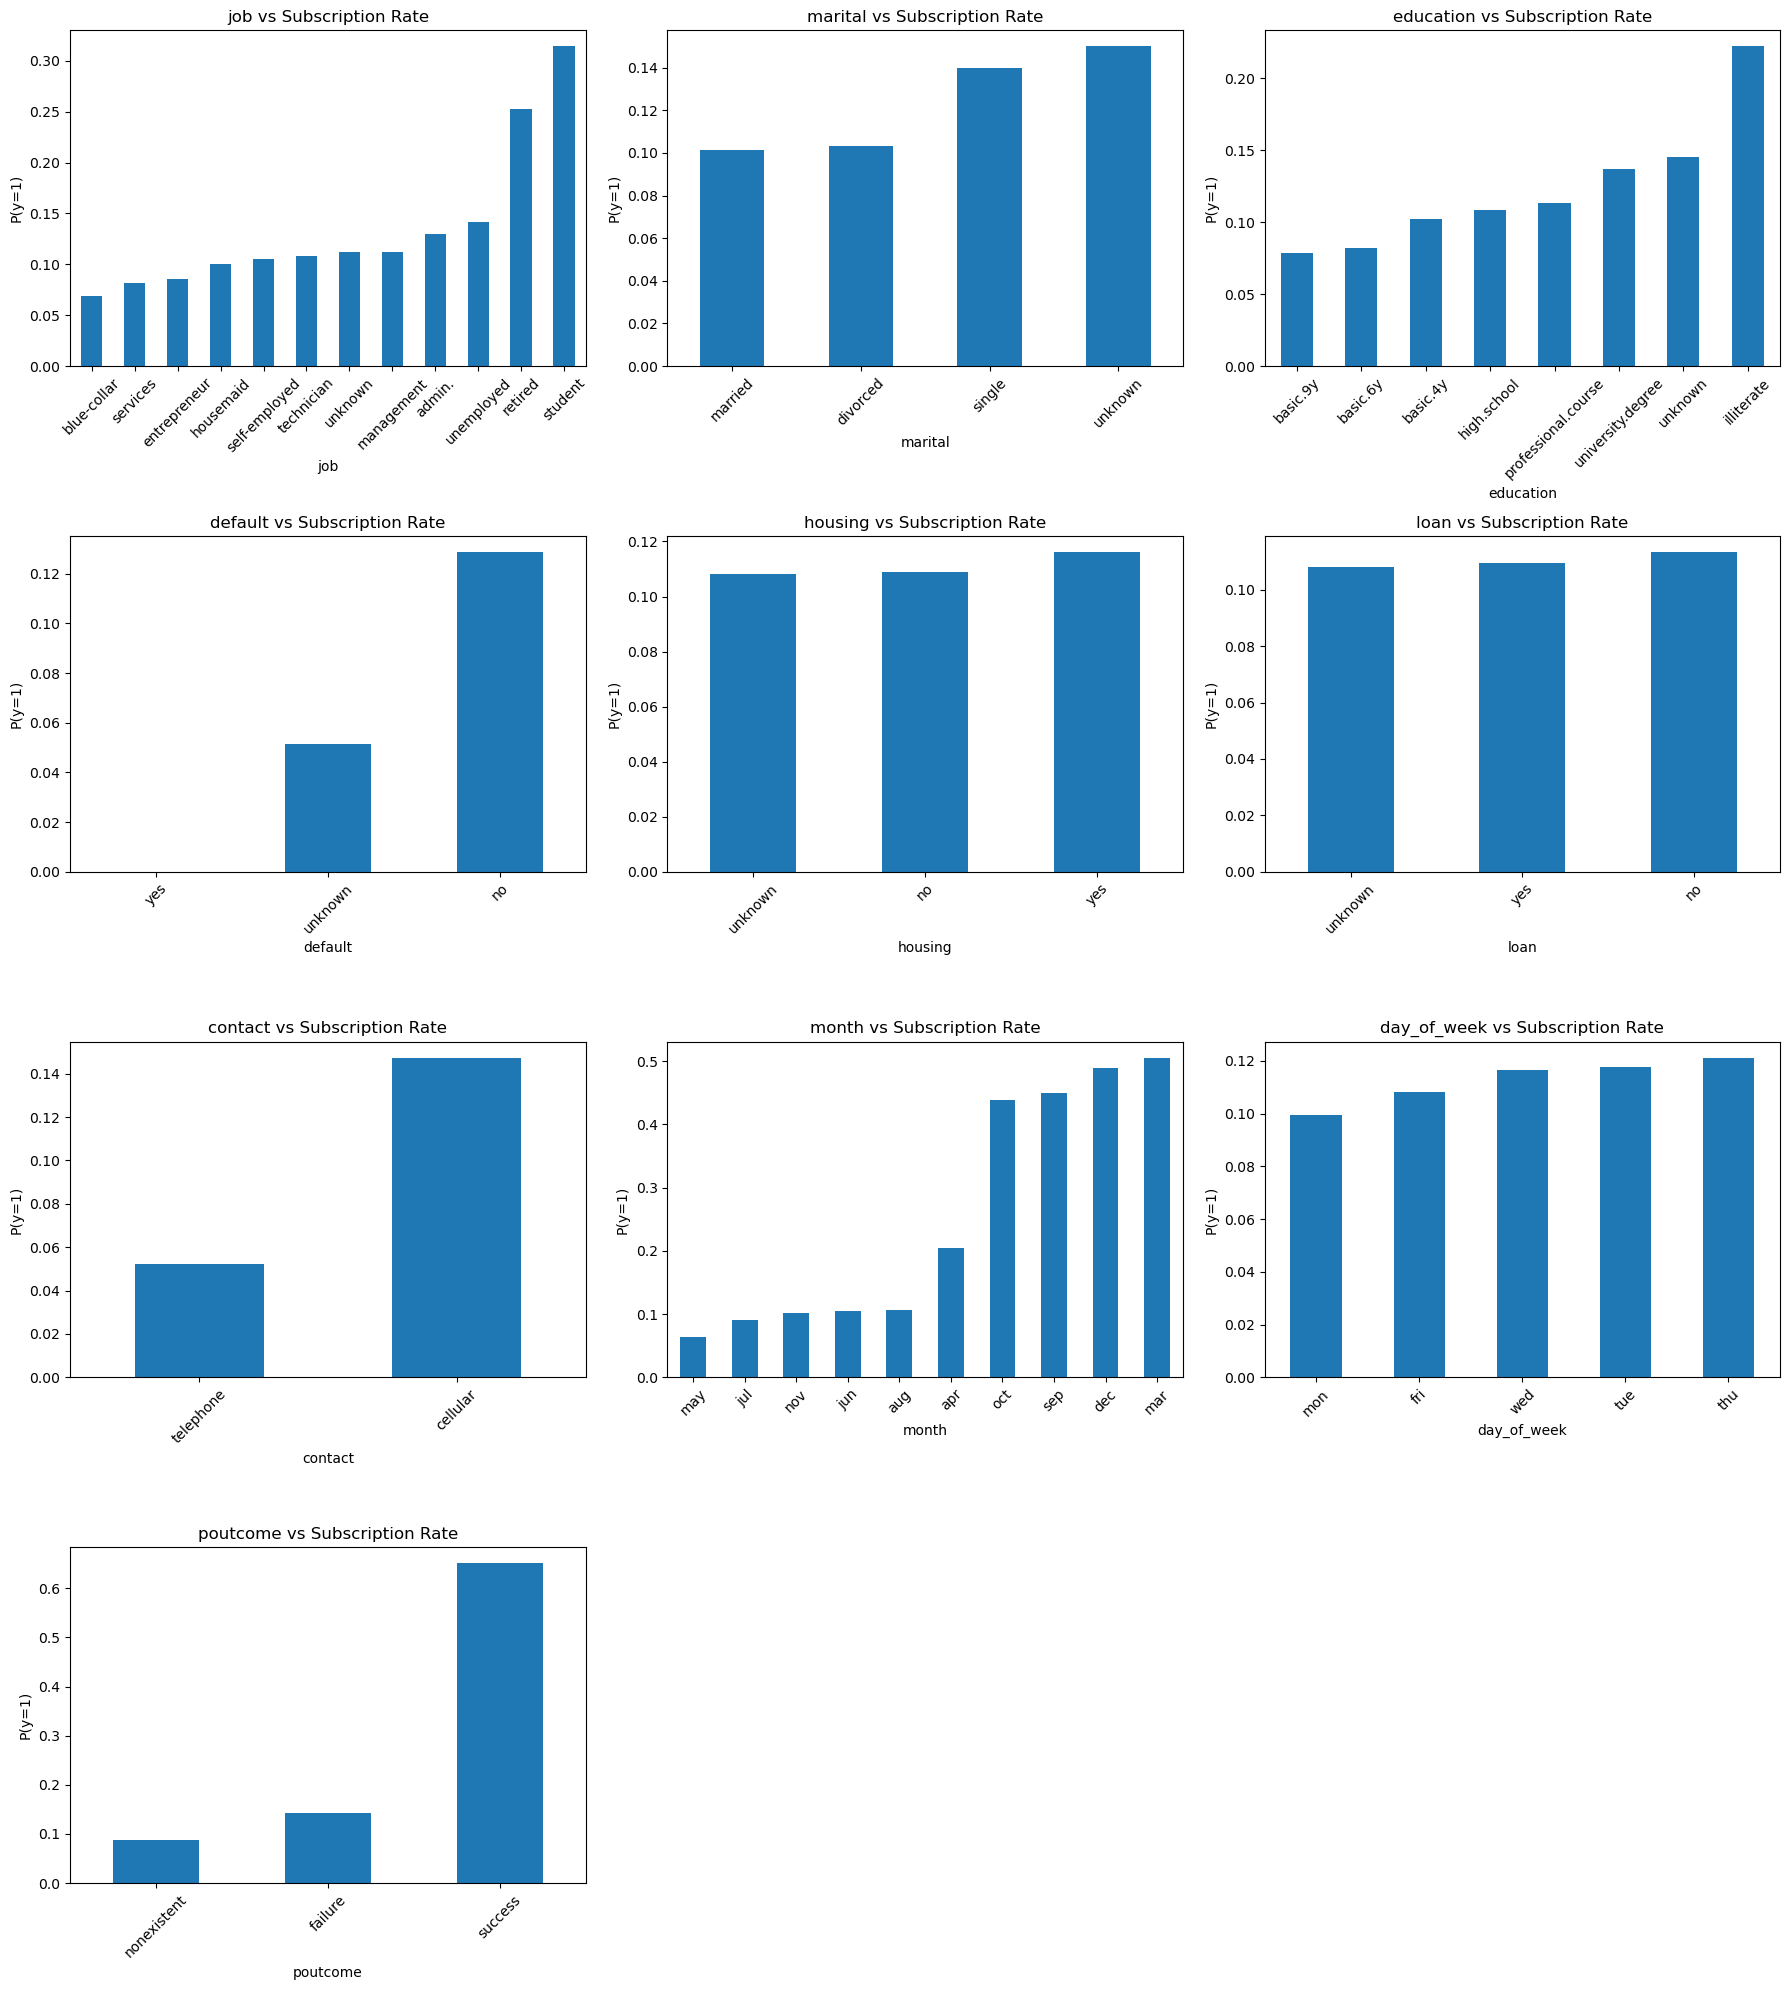

In [13]:
# Parten Observation
import math

df = campaign_Target_Encoding.copy()

# number of plots
n_cols = 3
n_rows = math.ceil(len(df.select_dtypes(include='object').columns) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(df.select_dtypes(include='object').columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # compute subscription rate
    rate = df.groupby(col)['y'].mean().sort_values()
    
    rate.plot(kind='bar')
    
    plt.title(f"{col} vs Subscription Rate")
    plt.ylabel("P(y=1)")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

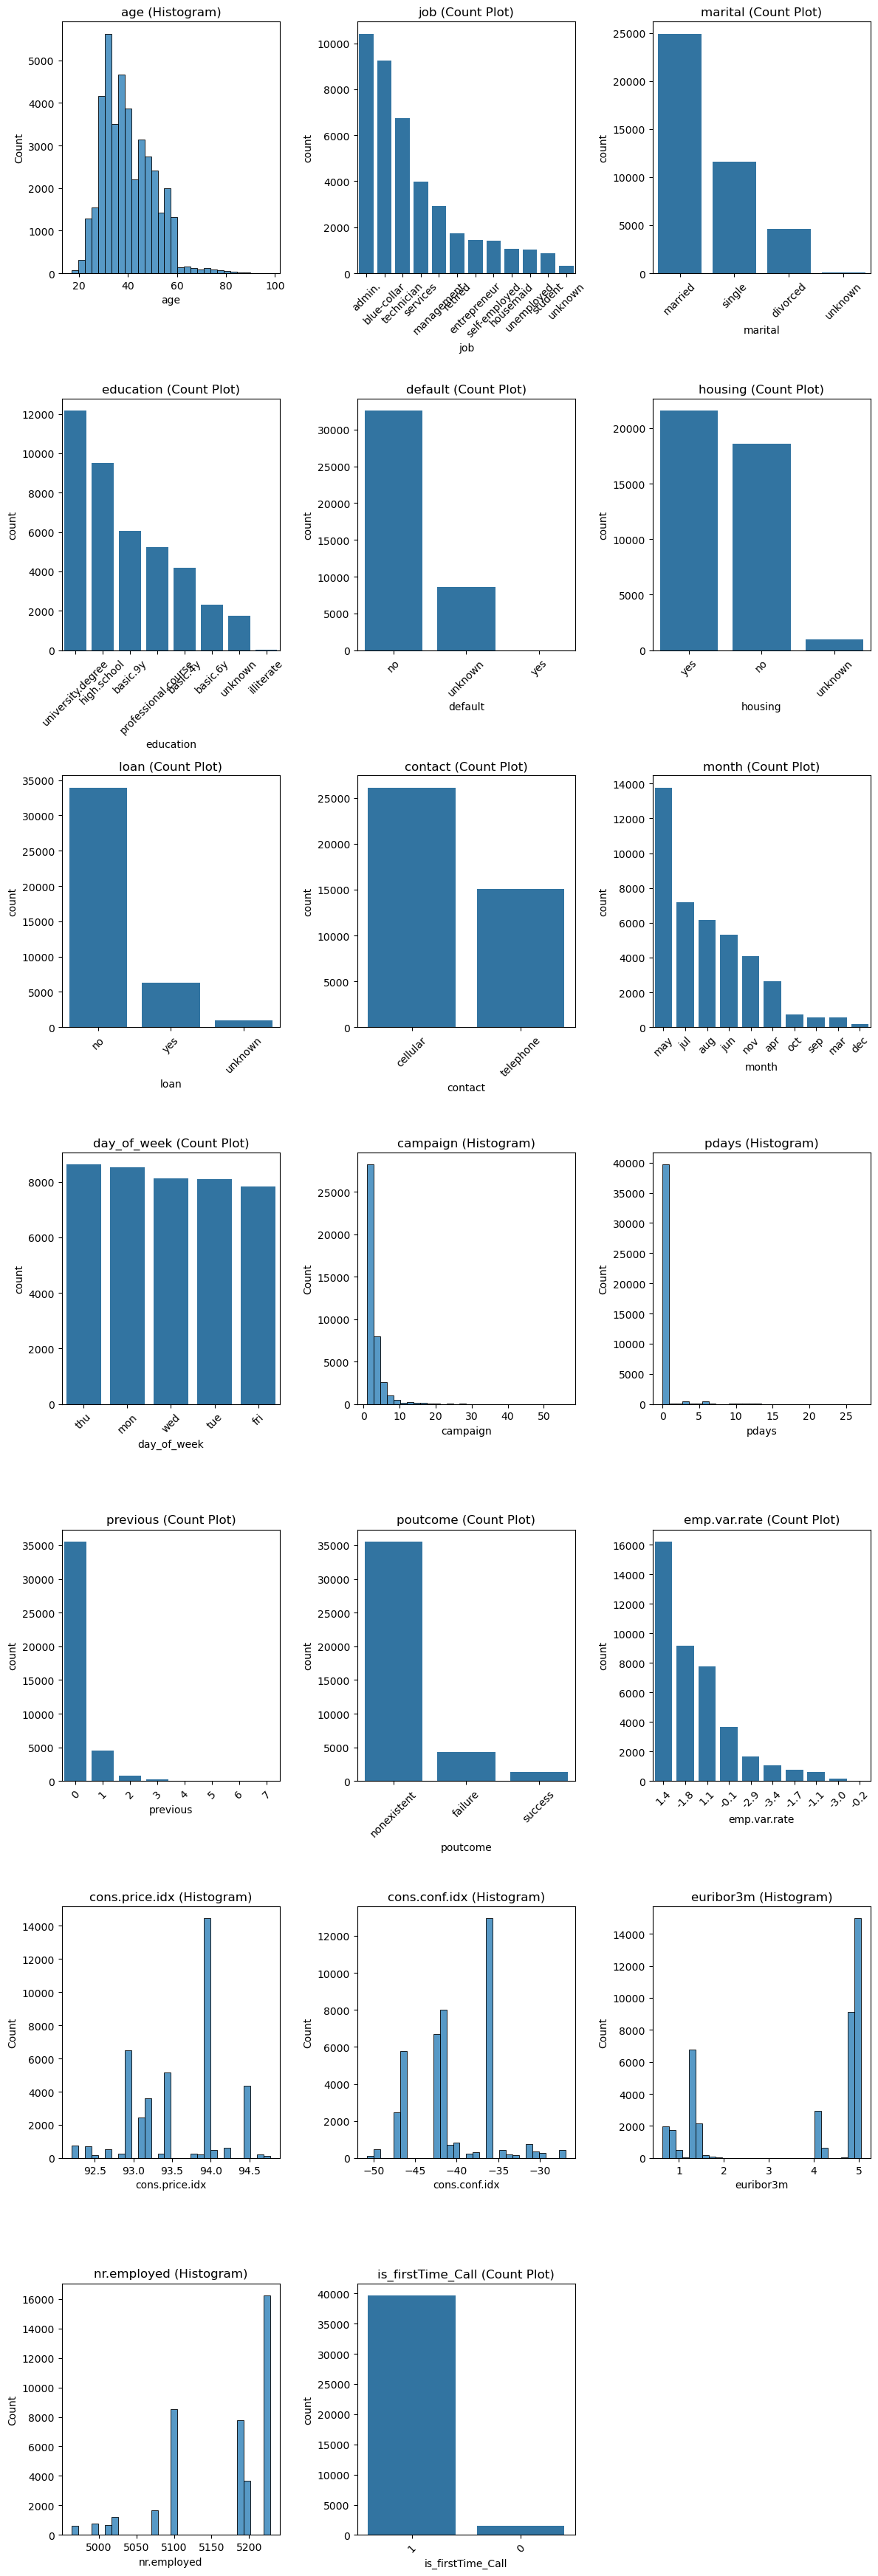

In [14]:
df = campaign_Target_Encoding.copy()

cols = df.columns.drop('y')  # exclude target
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    unique_vals = df[col].nunique()
    
    # If categorical OR few unique values → countplot
    if df[col].dtype == 'object' or unique_vals <= 10:
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.xticks(rotation=45)
        plt.title(f"{col} (Count Plot)")
    
    # Otherwise → histogram
    else:
        sns.histplot(data=df, x=col, bins=30)
        plt.title(f"{col} (Histogram)")
    
plt.tight_layout()
plt.show()


In [15]:
X = X.drop(columns=['housing', 'loan', 'default'])

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
#Column Type Identification
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns
#Preprocessor Set-up
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [17]:
Engineering_Features = {
    "Feature_Removal" :(
        "The feature of 'duration' was removed because it is unusable for real-world prediction. Additionally, categorical features "
        "such as 'housing','loan', and 'default' were removed due to their minimal variation in subscription rates, indicating low "
        "predicative value."
    ),
    "Feature_Transformation":(
        "The 'pdays' feature conatins a special value(999) indicating that the client was contacted the first time. To properly represent "
        "this infomration, a new binary numerical featrue 'is_firstTime_Call' was created. The origional values of 999 were replaced with 0. "
        "Also, the target variable 'y' was converted from categorical values to a binary numerical format to facilitate model training."
    ),
    "Feature_Typing":(
        "Features were separated into categorical and numerical groups based on data type to enable scaling and one-hot encoding techniques"
    )
}
for topic, description in Engineering_Features.items():
    print(f"•{topic}:\n{description}\n")

•Feature_Removal:
The feature of 'duration' was removed because it is unusable for real-world prediction. Additionally, categorical features such as 'housing','loan', and 'default' were removed due to their minimal variation in subscription rates, indicating low predicative value.

•Feature_Transformation:
The 'pdays' feature conatins a special value(999) indicating that the client was contacted the first time. To properly represent this infomration, a new binary numerical featrue 'is_firstTime_Call' was created. The origional values of 999 were replaced with 0. Also, the target variable 'y' was converted from categorical values to a binary numerical format to facilitate model training.

•Feature_Typing:
Features were separated into categorical and numerical groups based on data type to enable scaling and one-hot encoding techniques



### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,test_size=0.2,random_state=42
)

In [19]:
Train_Test_Split = {
    "Train distribution:" : (
        y_train.value_counts(normalize=True)
    ),
    "Test distribution:":(
        y_test.value_counts(normalize=True)
    ),

}
for topic, description in Train_Test_Split.items():
    print(f"•{topic}:\n{description}\n")

•Train distribution::
y
0    0.887557
1    0.112443
Name: proportion, dtype: float64

•Test distribution::
y
0    0.886502
1    0.113498
Name: proportion, dtype: float64



### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [20]:
from sklearn.dummy import DummyClassifier
#Three additional key performance indicators were introduced to improve the performance visibility of the model.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

In [21]:
Baseline_Model = {
    "BaseLine Model":(
        "The baseline model introduced DummyCalssifier, which predictes the majority calss for all oversavtion, "
        "which is the non-subscriber class. This model produces :"
    ),
    "Accuracy":(
        accuracy_score(y_test, y_pred_base)
    ),
    "Precision":(
        precision_score(y_test, y_pred_base, zero_division=0)
    ),
    "Recall":(
        recall_score(y_test, y_pred_base)
    ),
    "F1":(
        f1_score(y_test, y_pred_base)
    ),
    "Model Performance Expectations":(
        "Any meaningful classifier should optperform this baseline, and should be able yo identify potential subscribers."
    )    
}
for topic, description in Baseline_Model.items():
    print(f"•{topic}:\n{description}\n")

•BaseLine Model:
The baseline model introduced DummyCalssifier, which predictes the majority calss for all oversavtion, which is the non-subscriber class. This model produces :

•Accuracy:
0.8865015780529255

•Precision:
0.0

•Recall:
0.0

•F1:
0.0

•Model Performance Expectations:
Any meaningful classifier should optperform this baseline, and should be able yo identify potential subscribers.



### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [23]:
log_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
log_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'is_firstTime_Call'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'poutcome'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [24]:
y_pred_train = log_pipe.predict(X_train)
y_pred_test = log_pipe.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1:", f1_score(y_test, y_pred_test))

Training Accuracy: 0.9010015174506828
Test Accuracy: 0.8974265598446225
Precision: 0.6461038961038961
Recall: 0.21283422459893048
F1: 0.32019308125502816


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [25]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [26]:
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

In [27]:
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

In [28]:
results = []

results.append({
    "Model": "Baseline",
    "Train Time (s)": 0,
    "Train Accuracy": accuracy_score(y_train, baseline.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base),
    "F1": f1_score(y_test, y_pred_base)
})

for name, model in models.items():
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Train Time (s)": train_time,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred)
    })

comparison_df = pd.DataFrame(results)
from IPython.display import display
display(comparison_df.style.hide(axis="index"))

Model,Train Time (s),Train Accuracy,Test Accuracy,Precision,Recall,F1
Baseline,0.000000,0.887557,0.886502,0.000000,0.000000,0.000000
Logistic Regression,0.146778,0.901002,0.897427,0.646104,0.212834,0.320193
KNN,0.024424,0.913596,0.889536,0.524462,0.286631,0.370678
Decision Tree,0.146812,0.988194,0.844501,0.324187,0.341176,0.332465
SVM,27.979378,0.905736,0.896941,0.616848,0.242781,0.348427


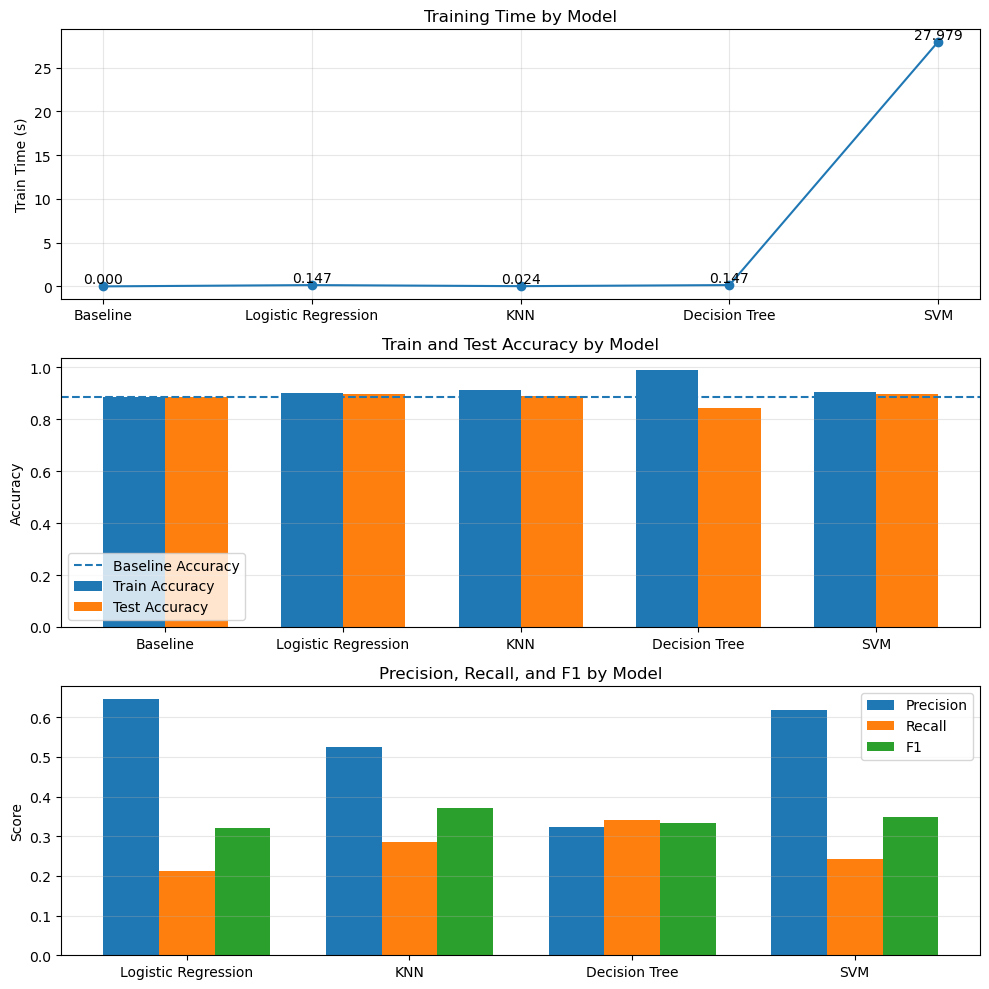

In [29]:
plot_df = comparison_df.copy().reset_index(drop=True)
models = plot_df["Model"]
train_time = plot_df["Train Time (s)"]
train_acc = plot_df["Train Accuracy"]
test_acc = plot_df["Test Accuracy"]
precision = plot_df["Precision"]
recall = plot_df["Recall"]
f1 = plot_df["F1"]
# BaseLine Model
baseline_test_acc = plot_df.loc[plot_df["Model"] == "Baseline", "Test Accuracy"].iloc[0]
kpi_df = plot_df[plot_df["Model"] != "Baseline"].copy()
kpi_models = kpi_df["Model"]

x = np.arange(len(models))
x_kpi = np.arange(len(kpi_models))
width = 0.35
width_kpi = 0.25

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
# 1) Training time line plot
axes[0].plot(models, train_time, marker='o')
axes[0].set_title("Training Time by Model")
axes[0].set_ylabel("Train Time (s)")
axes[0].grid(True, alpha=0.3)

for i, v in enumerate(train_time):
    axes[0].text(i, v, f"{v:.3f}", ha='center', va='bottom')

# 2) Train/Test accuracy bars + baseline model line
axes[1].bar(x - width/2, train_acc, width=width, label="Train Accuracy")
axes[1].bar(x + width/2, test_acc, width=width, label="Test Accuracy")
axes[1].axhline(y=baseline_test_acc, linestyle='--', label="Baseline Accuracy")

axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title("Train and Test Accuracy by Model")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Precision / Recall / F1 bar plot
axes[2].bar(x_kpi - width_kpi, kpi_df["Precision"], width=width_kpi, label="Precision")
axes[2].bar(x_kpi, kpi_df["Recall"], width=width_kpi, label="Recall")
axes[2].bar(x_kpi + width_kpi, kpi_df["F1"], width=width_kpi, label="F1")

axes[2].set_xticks(x_kpi)
axes[2].set_xticklabels(kpi_models)
axes[2].set_title("Precision, Recall, and F1 by Model")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
Model_Comparsion = {
    "Background": (
        "Four models with their default settings were tested: Logistic Regression, KNN, Decision Tree, and SVM. "
        "Their performance was compared in above plots, using training time, training accuracy, "
        "test accuracy, precision, recall, and F1-score."
    ),

    "Logistic Regression": (
        "Logistic Regression required 0.1609 seconds to train, achieved a training accuracy of 0.9010 and a test accuracy of 0.8974. "
        "Its precision was 0.6461, which was the highest among the tested models, meaning "
        "its prediction on potential subscribers were the most reliable. "
        "However, its recall was only 0.2128, showing that it missed many actual subscribers. "
        "Its F1-score was 0.3202, indicating a moderate balance between precision and recall."
    ),

    "KNN": (
        "KNN required only 0.0319 seconds to train, making it one of the fastest models. "
        "It achieved a training accuracy of 0.9136 and a test accuracy of 0.8895. "
        "Its precision was 0.5245 and its recall was 0.2866, both better balanced than Logistic Regression. "
        "Its F1-score was 0.3707, which was the highest among all tested models, suggesting that KNN with the default settings"
        " provided the best overall balance between correctly identifying subscribers and limiting false positives."
    ),

    "Decision Tree": (
        "Decision Tree required 0.1506 seconds to train, with a training accuracy of 0.9882 and a test accuracy of 0.8466. "
        "This large gap between training and test accuracy suggests strong overfitting. "
        "Its precision was 0.3281, recall was 0.3358, and F1-score was 0.3319. "
    ),

    "SVM": (
        "SVM required 23.8178 seconds to train, which was much slower than all other models. "
        "It achieved a training accuracy of 0.9057 and a test accuracy of 0.8969, showing good generalization performance. "
        "Its precision was 0.6168, recall was 0.2428, and F1-score was 0.3484. "
        "This indicates that SVM performed strongly overall, with high precision and competitive F1-score, but at a much higher computational cost."
    )
}

for topic, description in Model_Comparsion.items():
    print(f"•{topic}:\n{description}\n")

•Background:
Four models with their default settings were tested: Logistic Regression, KNN, Decision Tree, and SVM. Their performance was compared in above plots, using training time, training accuracy, test accuracy, precision, recall, and F1-score.

•Logistic Regression:
Logistic Regression required 0.1609 seconds to train, achieved a training accuracy of 0.9010 and a test accuracy of 0.8974. Its precision was 0.6461, which was the highest among the tested models, meaning its prediction on potential subscribers were the most reliable. However, its recall was only 0.2128, showing that it missed many actual subscribers. Its F1-score was 0.3202, indicating a moderate balance between precision and recall.

•KNN:
KNN required only 0.0319 seconds to train, making it one of the fastest models. It achieved a training accuracy of 0.9136 and a test accuracy of 0.8895. Its precision was 0.5245 and its recall was 0.2866, both better balanced than Logistic Regression. Its F1-score was 0.3707, whi

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [31]:
# Logistic Regression Fine Tuning C for Performance Optimization
results = []
C_values = np.linspace(0.01, 100, 500)

for C_val in C_values:
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=C_val, max_iter=1000))
    ])
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    results.append({
        "C": C_val,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred)
    })

lr_tuning_df = pd.DataFrame(results)
lr_tuning_df.head()

,C,Train Accuracy,Test Accuracy,F1
0,0.010000,0.901791,0.898155,0.311731
1,0.210381,0.901153,0.896941,0.318072
2,0.410762,0.900971,0.897062,0.318328
3,0.611142,0.901032,0.897669,0.320709
4,0.811523,0.901123,0.897548,0.320451


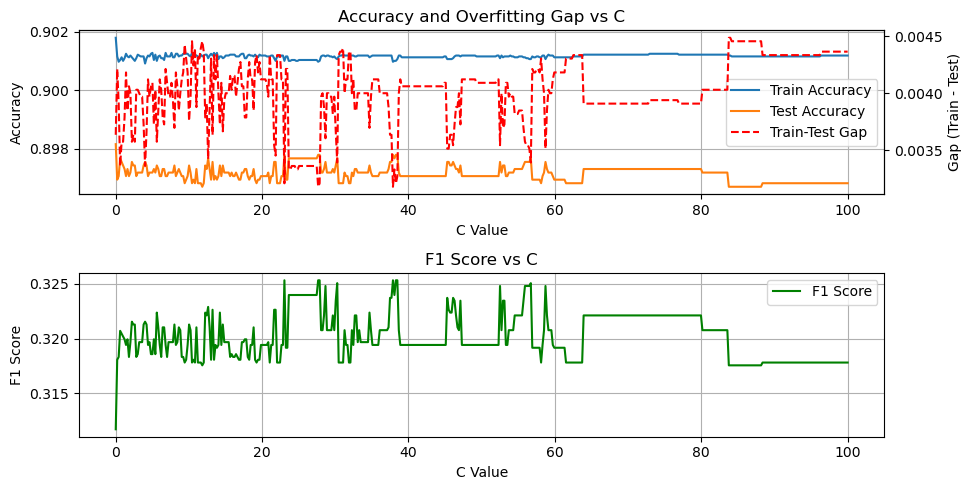

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

# 1) Accuracy + Gap Plot
ax1 = axes[0]

ax1.plot(lr_tuning_df["C"], lr_tuning_df["Train Accuracy"], label="Train Accuracy")
ax1.plot(lr_tuning_df["C"], lr_tuning_df["Test Accuracy"], label="Test Accuracy")
ax2 = ax1.twinx()
gap = lr_tuning_df["Train Accuracy"] - lr_tuning_df["Test Accuracy"]
ax2.plot(lr_tuning_df["C"], gap, linestyle='--', color='red', label="Train-Test Gap")
ax1.set_xlabel("C Value")
ax1.set_ylabel("Accuracy")
ax2.set_ylabel("Gap (Train - Test)")
ax1.set_title("Accuracy and Overfitting Gap vs C")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.grid(True)

# 2) F1 Plot
axes[1].plot(lr_tuning_df["C"], lr_tuning_df["F1"], color='green', label="F1 Score")

axes[1].set_xlabel("C Value")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs C")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [33]:
# The gap between the training accuracy and test accuracy barely chang along with increase C, indicating low risk of overfitting.
# So the hyperparameter for log_model is the one provide the best F1 score.
best_row = lr_tuning_df.loc[lr_tuning_df["F1"].idxmax()]

best_C = best_row["C"]
best_train_acc = best_row["Train Accuracy"]
best_test_acc = best_row["Test Accuracy"]
best_f1 = best_row["F1"]

print("Hyperparameter for log_model: C =", best_C)

Hyperparameter for log_model: C = 23.0537875751503


In [34]:
# KNN Fine Tuning number of neighbors for Performance Optimization
from sklearn.model_selection import GridSearchCV

knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': list(range(1, 100))
}

knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X_train, y_train)

print("Best params:", knn_grid.best_params_)
print("Best CV F1:", knn_grid.best_score_)

Best params: {'classifier__n_neighbors': 11}
Best CV F1: 0.38657996709376674


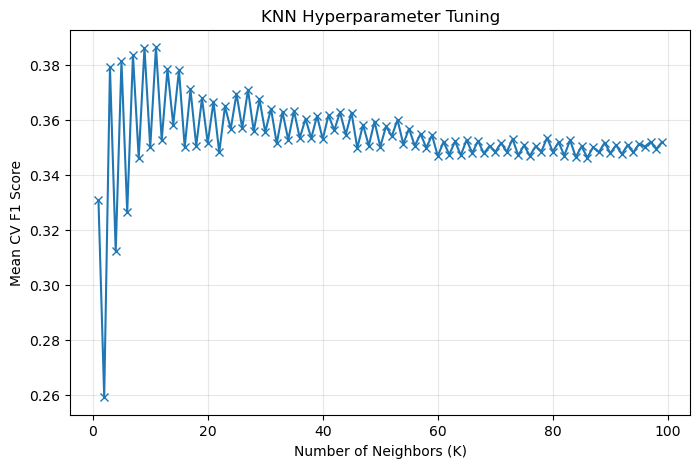

In [35]:
cv_results = pd.DataFrame(knn_grid.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(
    cv_results['param_classifier__n_neighbors'].astype(int),
    cv_results['mean_test_score'],
    marker='x'
)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV F1 Score")
plt.title("KNN Hyperparameter Tuning")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
#Decision Tree Fine Tuning the maximum depth for Performance Optimization
tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

tree_param_grid = {
    'classifier__max_depth': list(range(1, 100))
}

tree_grid = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

tree_grid.fit(X_train, y_train)

print("Best params:", tree_grid.best_params_)
print("Best CV F1:", tree_grid.best_score_)

Best params: {'classifier__max_depth': 10}
Best CV F1: 0.3943987094642423


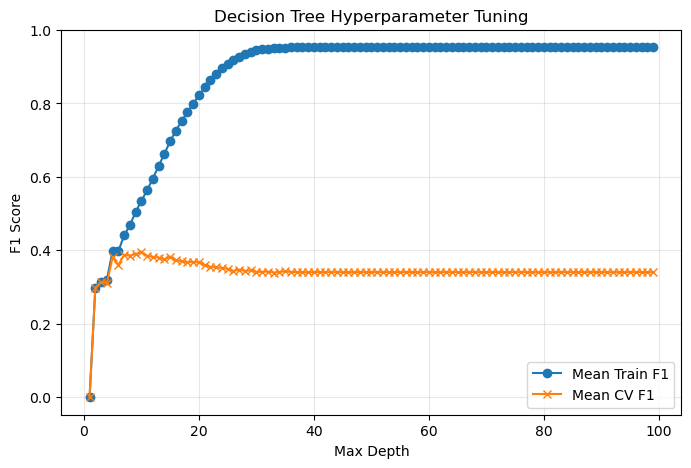

In [40]:
tree_cv_results = pd.DataFrame(tree_grid.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(
    tree_cv_results['param_classifier__max_depth'].astype(int),
    tree_cv_results['mean_train_score'],
    marker='o',
    label='Mean Train F1'
)

plt.plot(
    tree_cv_results['param_classifier__max_depth'].astype(int),
    tree_cv_results['mean_test_score'],
    marker='x',
    label='Mean CV F1'
)

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree Hyperparameter Tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
#SVM Fine Tuning for Performance Optimization
#Step by step improvement: 1. Kernel
svm_kernel_results = []

for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel=kernel))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    svm_kernel_results.append({
        "kernel": kernel,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

kernel_df = pd.DataFrame(svm_kernel_results)
print(kernel_df)

    kernel  accuracy  precision    recall        f1
0   linear  0.894756   0.608974  0.203209  0.304731
1      rbf  0.896941   0.616848  0.242781  0.348427
2     poly  0.894392   0.598187  0.211765  0.312796
3  sigmoid  0.836854   0.265212  0.247059  0.255814


In [42]:
#Step by step improvement: 2. C with the best Kernel(rbf) from step 1
c_values = np.linspace(0.1, 100, 30)

svm_c_results = []

for C in c_values:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', C=C))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    svm_c_results.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

svm_c_df = pd.DataFrame(svm_c_results)

print(svm_c_df.head(10))

           C  Accuracy  Precision    Recall        F1
0   0.100000  0.897305   0.669202  0.188235  0.293823
1   3.544828  0.895606   0.604457  0.232086  0.335394
2   6.989655  0.893906   0.578005  0.241711  0.340875
3  10.434483  0.893421   0.569007  0.251337  0.348665
4  13.879310  0.894149   0.573427  0.263102  0.360704
5  17.324138  0.892692   0.558087  0.262032  0.356623
6  20.768966  0.892450   0.553611  0.270588  0.363506
7  24.213793  0.890629   0.536017  0.270588  0.359630
8  27.658621  0.890872   0.537344  0.277005  0.365561
9  31.103448  0.890022   0.529774  0.275936  0.362869


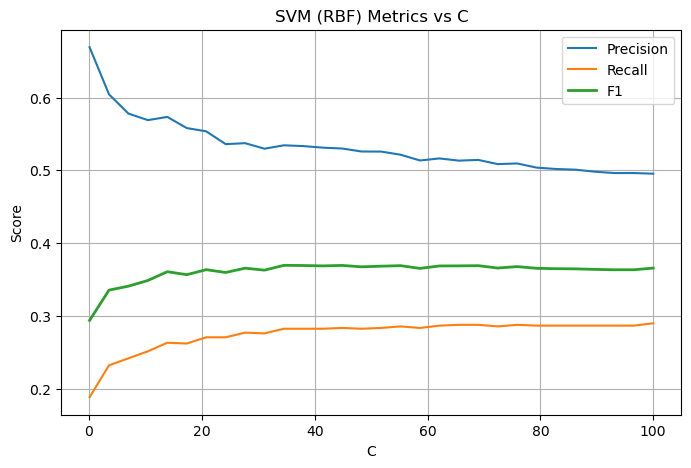

In [43]:
plt.figure(figsize=(8,5))

plt.plot(svm_c_df["C"], svm_c_df["Precision"], label="Precision")
plt.plot(svm_c_df["C"], svm_c_df["Recall"], label="Recall")
plt.plot(svm_c_df["C"], svm_c_df["F1"], label="F1", linewidth=2)

plt.xlabel("C")
plt.ylabel("Score")
plt.title("SVM (RBF) Metrics vs C")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# The plot showing as C increase, the F1 score improves, indicating better balance between precison and recall. 
# However, beyond a certain point, performance stabilized, indicating the optimal C is the one maximized F1-score.
best_row = svm_c_df.loc[svm_c_df["F1"].idxmax()]

best_C = best_row["C"]

print("The hyperparamter of C for SVM:", best_C)

The hyperparamter of C for SVM: 34.54827586206897


In [48]:
#Step by step improvement: 3. gamma with the best Kernel(rbf) from step 1 and C from step 2
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]

svm_gamma_results = []

for gamma in gamma_values:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', C=34.54827586206897, gamma=gamma))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    svm_gamma_results.append({
        "gamma": gamma,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

svm_gamma_df = pd.DataFrame(svm_gamma_results)

print(svm_gamma_df)

    gamma  Accuracy  Precision    Recall        F1
0  0.0001  0.894756   0.608974  0.203209  0.304731
1  0.0010  0.897791   0.667870  0.197861  0.305281
2  0.0100  0.896455   0.611413  0.240642  0.345357
3  0.1000  0.887351   0.506422  0.295187  0.372973
4  1.0000  0.860282   0.239130  0.105882  0.146775


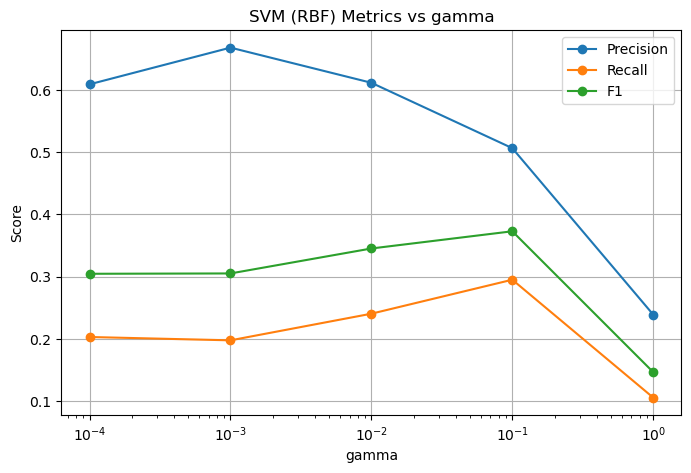

In [50]:
plt.figure(figsize=(8,5))
plt.semilogx(svm_gamma_df["gamma"], svm_gamma_df["Precision"], marker='o', label="Precision")
plt.semilogx(svm_gamma_df["gamma"], svm_gamma_df["Recall"], marker='o', label="Recall")
plt.semilogx(svm_gamma_df["gamma"], svm_gamma_df["F1"], marker='o', label="F1")

plt.xlabel("gamma")
plt.ylabel("Score")
plt.title("SVM (RBF) Metrics vs gamma")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
best_gamma_row = svm_gamma_df.loc[svm_gamma_df["F1"].idxmax()]
best_gamma = best_gamma_row["gamma"]
print("Best gamma:", best_gamma)

Best gamma: 0.1


In [54]:
tuned_models = {
    "Logistic Regression (Tuned)": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=23.0537875751503, max_iter=1000))
    ]),
    
    "KNN (Tuned)": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=11))
    ]),
    
    "Decision Tree (Tuned)": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ))
    ]),
    
    "SVM (Tuned)": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(
            kernel='rbf',
            C=34.54827586206897,
            gamma=0.1
        ))
    ])
}

In [55]:
from sklearn.model_selection import cross_val_score
results = []
results.append({
    "Model": "Baseline",
    "Train Time (s)": 0,
    "CV F1": 0,
    "Train Accuracy": accuracy_score(y_train, baseline.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base),
    "F1": f1_score(y_test, y_pred_base)
})
for name, model in tuned_models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
    results.append({
        "Model": name,
        "Train Time (s)": train_time,
        "CV F1": cv_scores.mean(),
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df.style.hide(axis="index"))

Model,Train Time (s),CV F1,Train Accuracy,Test Accuracy,Precision,Recall,F1
Baseline,0.000000,0.000000,0.887557,0.886502,0.000000,0.000000,0.000000
Logistic Regression (Tuned),0.129573,0.344609,0.901002,0.897791,0.648562,0.217112,0.325321
KNN (Tuned),0.023743,0.370590,0.905797,0.894270,0.576923,0.256684,0.355292
Decision Tree (Tuned),0.095793,0.369969,0.916935,0.890265,0.526316,0.331551,0.406824
SVM (Tuned),60.761970,0.365912,0.945584,0.887351,0.506422,0.295187,0.372973


In [56]:
Improved_Model_Comparison = {
    "Best_Model": (
        "Among the tuned models, the Decision Tree achieved the best overall performance. "
        "It produced the highest test F1-score (0.4068) and the highest recall (0.3316), "
        "while maintaining reasonable precision (0.5263) and low training time. "
    )
}
for topic, description in Improved_Model_Comparison.items():
    print(f"•{topic}:\n{description}\n")

•Best_Model:
Among the tuned models, the Decision Tree achieved the best overall performance. It produced the highest test F1-score (0.4068) and the highest recall (0.3316), while maintaining reasonable precision (0.5263) and low training time. 



##### Questions